**Dataset Pre-processing**

In [3]:
from google.colab import files
uploaded = files.upload()  # Click button → select "Updated_Obesity_Dataset.csv"

Saving Updated_Obesity_Dataset.csv to Updated_Obesity_Dataset.csv


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import math

df = pd.read_csv("Updated_Obesity_Dataset.csv")

print("=" * 50)
print("ORIGINAL DATASET")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nData Types:\n{df.dtypes}")

# Numeric columns → fill with mean
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    null_count = df[col].isnull().sum()          # check BEFORE filling
    if null_count > 0:
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)        # ← fixed: no inplace warning
        print(f"[NULL FIX] '{col}' — filled {null_count} nulls with mean = {mean_val:.4f}")

# Categorical columns → fill with MODE for object columns (safety net)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    null_count = df[col].isnull().sum()          # check BEFORE filling
    if null_count > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)        # ← fixed: no inplace warning
        print(f"[NULL FIX] '{col}' — filled {null_count} nulls with mode = '{mode_val}'")

print(f"\nMissing values after fix: {df.isnull().sum().sum()}")  # Should be 0

def standard_round(x):
    """Standard rounding: .5 and above → up, below .5 → down"""
    return math.floor(x + 0.5)

cols_to_round = ['Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for col in cols_to_round:
    if col in df.columns:
        df[col] = df[col].apply(standard_round)
        print(f"[ROUNDED] '{col}' → sample: {df[col].head(5).tolist()}")


# --- 4a. Binary Encoding (yes=1, no=0) ---
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'yes': 1, 'no': 0})
        print(f"[ENCODED - Binary] '{col}'")

# --- 4b. Gender ---
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
    print("[ENCODED - Binary] 'Gender' (Male=1, Female=0)")

# --- 4c. Ordinal Encoding (frequency-based order) ---
caec_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
if 'CAEC' in df.columns:
    df['CAEC'] = df['CAEC'].map(caec_order)
    print("[ENCODED - Ordinal] 'CAEC'")

calc_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
if 'CALC' in df.columns:
    df['CALC'] = df['CALC'].map(calc_order)
    print("[ENCODED - Ordinal] 'CALC'")

# --- 4d. One-Hot Encoding (MTRANS — no natural order) ---
if 'MTRANS' in df.columns:
    df = pd.get_dummies(df, columns=['MTRANS'], prefix='MTRANS', dtype=int)
    print("[ENCODED - One-Hot] 'MTRANS'")

# --- 4e. Target Column — Ordinal Encoding ---
obesity_order = {
    'Insufficient_Weight': 0,
    'Normal_Weight':       1,
    'Overweight_Level_I':  2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I':      4,
    'Obesity_Type_II':     5,
    'Obesity_Type_III':    6
}
if 'NObeyesdad' in df.columns:
    df['NObeyesdad'] = df['NObeyesdad'].map(obesity_order)
    print("[ENCODED - Ordinal] 'NObeyesdad' (target)")


scale_cols = ['Age', 'Height', 'Weight']
scale_cols = [col for col in scale_cols if col in df.columns]

scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
print(f"\n[SCALED - MinMax] Columns: {scale_cols}")

print("\n" + "=" * 50)
print("PROCESSED DATASET")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nFirst 5 Rows:\n{df.head()}")
print(f"\nStatistics:\n{df.describe()}")


df.to_csv("Obesity_Preprocessed.csv", index=False)
print("Save The File → Obesity_Preprocessed.csv")

ORIGINAL DATASET
Shape: (2111, 17)

Missing Values:
Age                                0
Gender                            11
Height                             0
Weight                             0
CALC                               0
FAVC                               0
FCVC                               0
NCP                                0
SCC                                0
SMOKE                              0
CH2O                              21
family_history_with_overweight    21
FAF                                0
TUE                                0
CAEC                               0
MTRANS                             0
NObeyesdad                         0
dtype: int64

Data Types:
Age                               float64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                              float64

In [5]:
files.download("Obesity_Preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Supervised models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Unsupervised
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

---
# **LOAD DATASET**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Obesity_Preprocessed.csv to Obesity_Preprocessed.csv


In [ ]:
dataset = pd.read_csv('Obesity_Preprocessed.csv')

---
# **EDA**

### **Summarize data**

In [ ]:
dataset

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,...,family_history_with_overweight,FAF,TUE,CAEC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.148936,0,0.320755,0.186567,0,0,2,3,0,0,...,1,0,1,1,1,0,0,0,1,0
1,0.148936,0,0.132075,0.126866,1,0,3,3,1,1,...,1,3,0,1,1,0,0,0,1,0
2,0.191489,1,0.660377,0.283582,2,0,2,3,0,0,...,1,2,1,1,1,0,0,0,1,0
3,0.276596,1,0.660377,0.358209,2,0,3,3,0,0,...,0,2,0,1,2,0,0,0,0,1
4,0.170213,1,0.622642,0.380597,1,0,2,1,0,0,...,0,0,0,1,3,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0.148443,0,0.491943,0.686567,1,1,3,3,0,0,...,1,2,1,1,6,0,0,0,1,0
2107,0.169850,0,0.563366,0.708955,1,1,3,3,0,0,...,1,1,1,1,6,0,0,0,1,0
2108,0.181362,0,0.570200,0.708955,1,1,3,3,0,0,...,1,1,1,1,6,0,0,0,1,0
2109,0.220467,0,0.546132,0.701493,1,1,3,3,0,0,...,1,1,1,1,6,0,0,0,1,0


In [ ]:
dataset.head(10)

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,...,family_history_with_overweight,FAF,TUE,CAEC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.148936,0,0.320755,0.186567,0,0,2,3,0,0,...,1,0,1,1,1,0,0,0,1,0
1,0.148936,0,0.132075,0.126866,1,0,3,3,1,1,...,1,3,0,1,1,0,0,0,1,0
2,0.191489,1,0.660377,0.283582,2,0,2,3,0,0,...,1,2,1,1,1,0,0,0,1,0
3,0.276596,1,0.660377,0.358209,2,0,3,3,0,0,...,0,2,0,1,2,0,0,0,0,1
4,0.170213,1,0.622642,0.380597,1,0,2,1,0,0,...,0,0,0,1,3,0,0,0,1,0
5,0.319149,1,0.320755,0.104478,1,1,2,3,0,0,...,0,0,0,1,1,1,0,0,0,0
6,0.191489,0,0.094340,0.119403,1,1,3,3,0,0,...,1,1,0,1,1,0,0,1,0,0
7,0.170213,1,0.358491,0.104478,1,0,2,3,0,0,...,0,3,0,1,1,0,0,0,1,0
8,0.212766,1,0.622642,0.186567,2,1,3,3,0,0,...,1,1,1,1,1,0,0,0,1,0
9,0.170213,1,0.509434,0.216418,0,1,2,3,0,0,...,1,1,1,1,1,0,0,0,1,0


In [ ]:
print('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(
    dataset.shape, dataset.shape[0], dataset.shape[1]))

Shape of the dataset is (2111, 21). This dataset contains 2111 rows and 21 columns.


### **Feature Names and its Datatypes**

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   int64  
 5   FAVC                            2111 non-null   int64  
 6   FCVC                            2111 non-null   int64  
 7   NCP                             2111 non-null   int64  
 8   SCC                             2111 non-null   int64  
 9   SMOKE                           2111 non-null   int64  
 10  CH2O                            2111 non-null   int64  
 11  family_history_with_overweight  2111 non-null   int64  
 12  FAF                             21

### **Selecting Numerical and Categorical Features**
#### Select and separately store Numerical and Categorical features in different variables.

> Since all features have already been encoded to numbers during preprocessing, we separate them by dtype:
> **float64** columns (Age, Height, Weight) are treated as continuous numerical features.
> **int64** columns (binary, ordinal, one-hot encoded) are treated as discrete/categorical features.

In [ ]:
# Selecting numerical (continuous float) features
numerical_data = dataset.select_dtypes(include=['float64'])
numerical_features = numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:\n')
print(numerical_features)

There are 3 numerical features:

['Age', 'Height', 'Weight']


In [ ]:
# Selecting discrete/encoded features (int64)
categorical_data = dataset.select_dtypes(include=['int64'])
categorical_features = categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} discrete/encoded features:\n')
print(categorical_features)

There are 18 discrete/encoded features:

['Gender', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'NObeyesdad', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


### **Descriptive Analysis**
#### **Summary Statistics of Numerical Features**

In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,0.219417,0.135021,0.0,0.126536,0.186764,0.255319,1.0
Height,2111.0,0.474863,0.176047,0.0,0.339623,0.472640,0.600875,1.0
Weight,2111.0,0.355140,0.195437,0.0,0.197761,0.328358,0.507463,1.0


### **Summary Statistics of Discrete/Encoded Features**

In [ ]:
categorical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,2111.0,0.509711,0.500024,0.0,0.0,1.0,1.0,1.0
CALC,2111.0,0.731407,0.515498,0.0,0.0,1.0,1.0,3.0
FAVC,2111.0,0.883941,0.320371,0.0,1.0,1.0,1.0,1.0
FCVC,2111.0,2.423496,0.583905,1.0,2.0,2.0,3.0,3.0
NCP,2111.0,2.687826,0.809680,1.0,3.0,3.0,3.0,4.0
SCC,2111.0,0.045476,0.208395,0.0,0.0,0.0,0.0,1.0
SMOKE,2111.0,0.020843,0.142893,0.0,0.0,0.0,0.0,1.0
CH2O,2111.0,2.015632,0.685836,1.0,2.0,2.0,2.0,3.0
family_history_with_overweight,2111.0,0.818096,0.385857,0.0,1.0,1.0,1.0,1.0
FAF,2111.0,1.006632,0.895462,0.0,0.0,1.0,2.0,3.0


### **Variance of each numerical feature**

In [ ]:
numerical_data.var()

,0
Age,0.018231
Height,0.030992
Weight,0.038196


### **Skew in numerical features**

📐 **What is Skewness?**
Skewness measures the asymmetry of the distribution of a dataset.

- Skewness = 0 → Perfectly symmetrical
- Skewness < 0 → Left-skewed (long tail on the left)
- Skewness > 0 → Right-skewed (long tail on the right)

| Skewness Value | Interpretation |
|---|---|
| ~ 0 | Symmetrical |
| 0 to ±0.5 | Fairly symmetrical |
| ±0.5 to ±1 | Moderately skewed |
| > ±1 | Highly skewed |

In [ ]:
numerical_data.skew()

,0
Age,1.529100
Height,-0.012855
Weight,0.255851


### **Histograms and Box Plots**
#### To find distributions and outliers in each feature

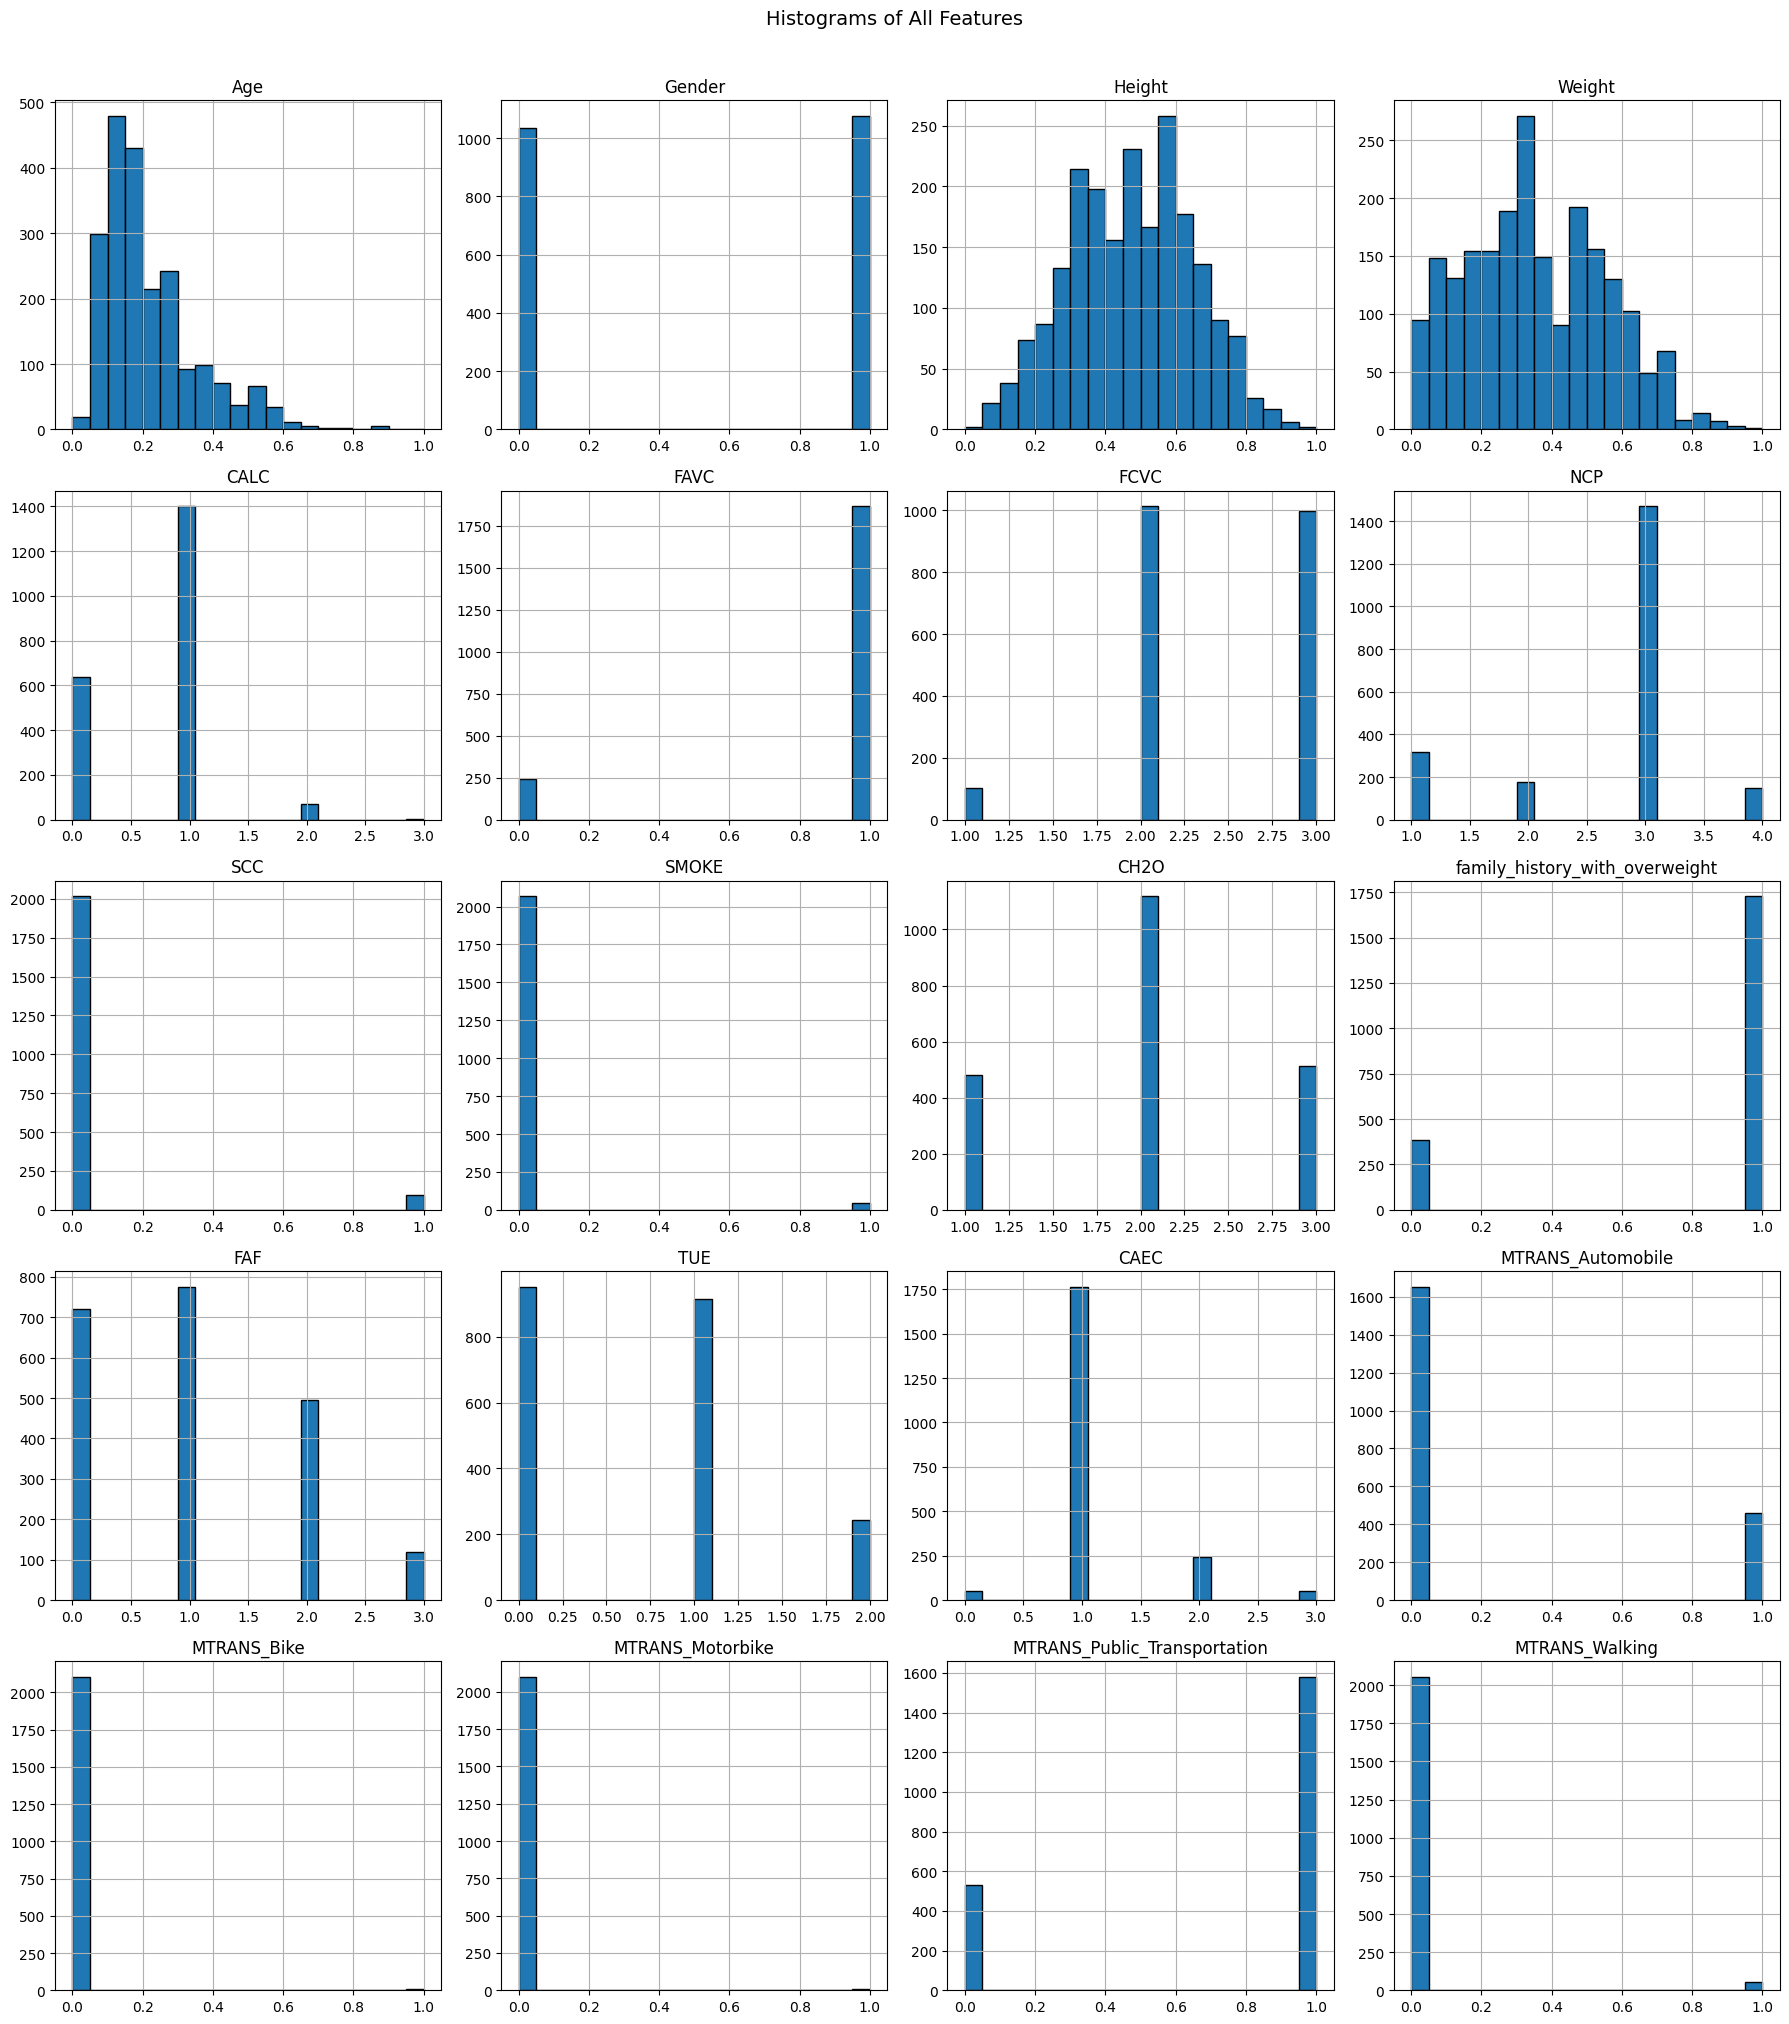

In [ ]:
# Histograms for all input features (excluding target)
dataset.drop(columns=['NObeyesdad']).hist(figsize=(18, 20), bins=20, layout=(5, 4), edgecolor='black')
plt.suptitle('Histograms of All Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### **Number of Unique Values in each Numerical Feature**

In [ ]:
numerical_data.nunique()

,0
Age,1402
Height,1574
Weight,118


### **Missing Values**

In [ ]:
print('--- Numerical Features ---')
print(numerical_data.isnull().sum())

print('\n--- Discrete/Encoded Features ---')
print(categorical_data.isnull().sum())

# Note: All 53 missing values were fixed during preprocessing
# (CH2O: 21 → mean fill, Gender: 11 → mode fill, family_history: 21 → mode fill)

--- Numerical Features ---
Age       0
Height    0
Weight    0
dtype: int64

--- Discrete/Encoded Features ---
Gender                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
NObeyesdad                        0
MTRANS_Automobile                 0
MTRANS_Bike                       0
MTRANS_Motorbike                  0
MTRANS_Public_Transportation      0
MTRANS_Walking                    0
dtype: int64


### **Discrete / Encoded Features**
#### **No of unique values in each discrete feature**

In [ ]:
unique_counts = categorical_data.nunique()
print(unique_counts)

Gender                            2
CALC                              4
FAVC                              2
FCVC                              3
NCP                               4
SCC                               2
SMOKE                             2
CH2O                              3
family_history_with_overweight    2
FAF                               4
TUE                               3
CAEC                              4
NObeyesdad                        7
MTRANS_Automobile                 2
MTRANS_Bike                       2
MTRANS_Motorbike                  2
MTRANS_Public_Transportation      2
MTRANS_Walking                    2
dtype: int64


### **Bar plot of unique value counts in every discrete feature**

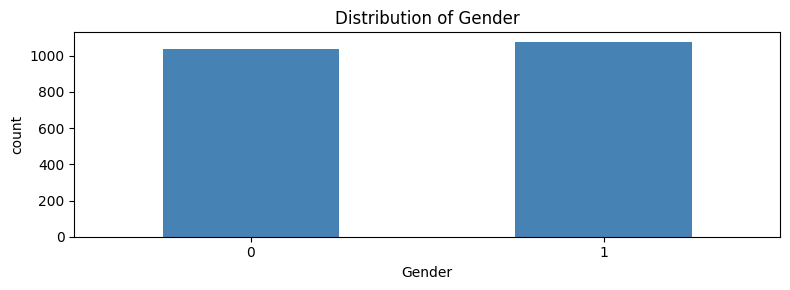

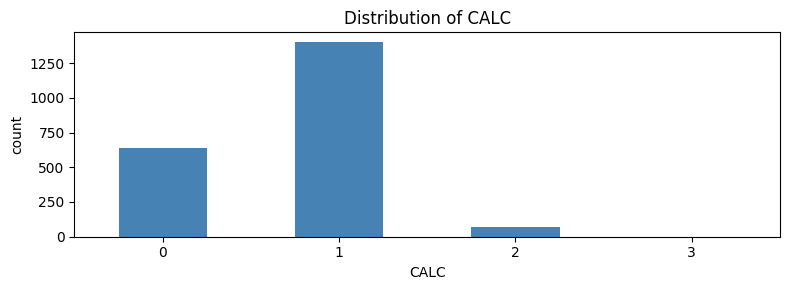

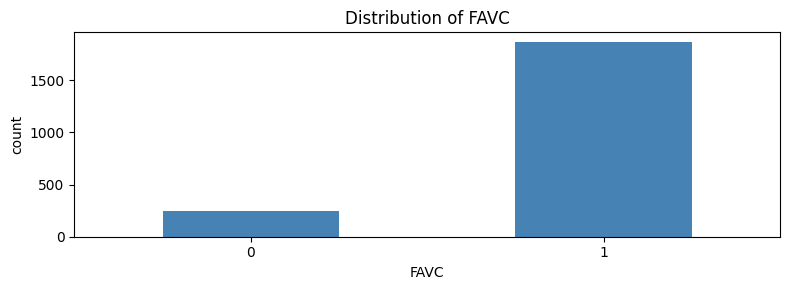

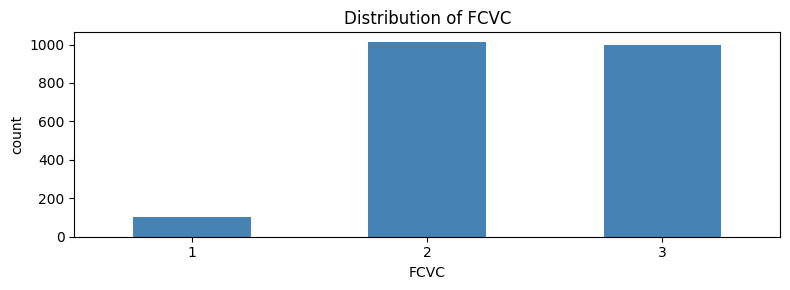

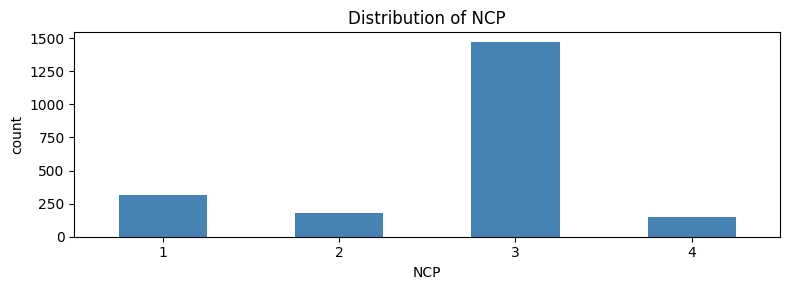

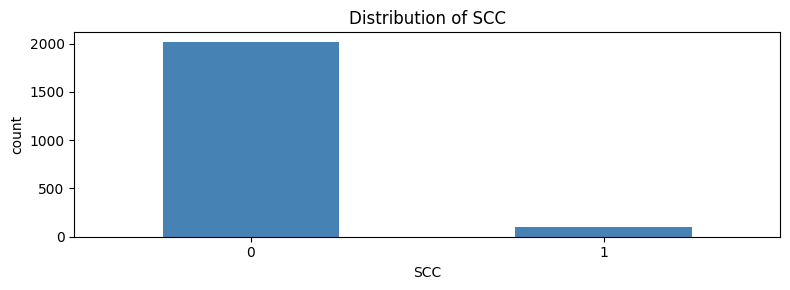

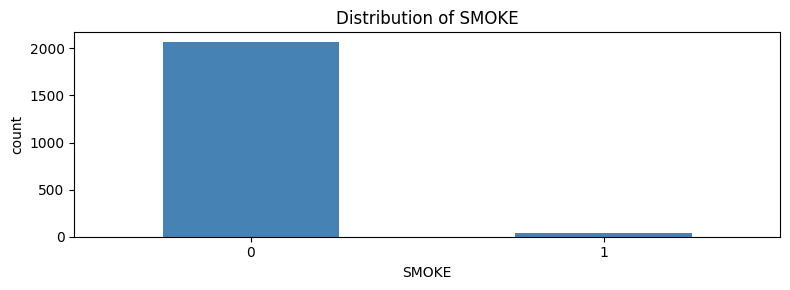

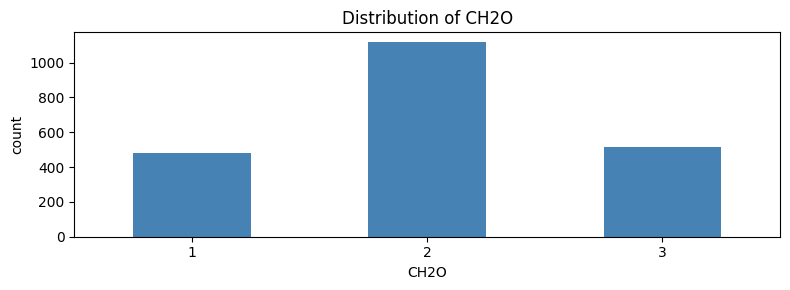

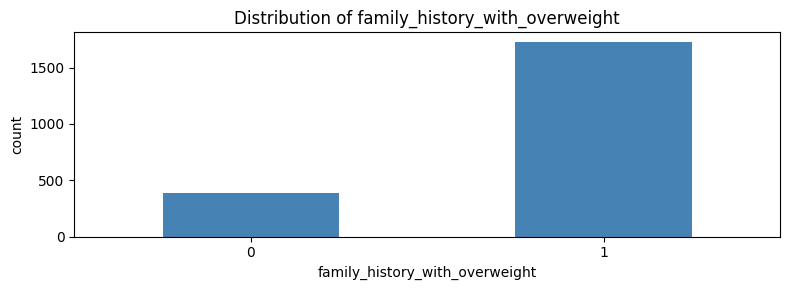

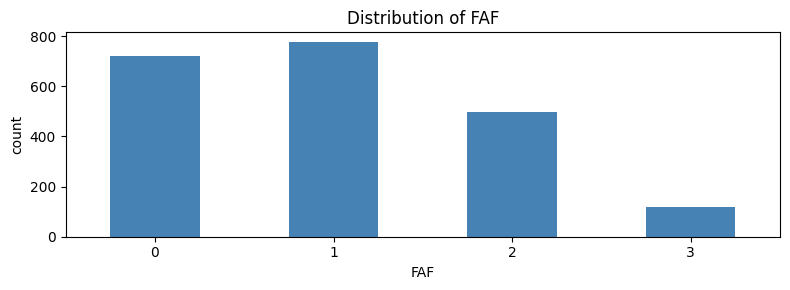

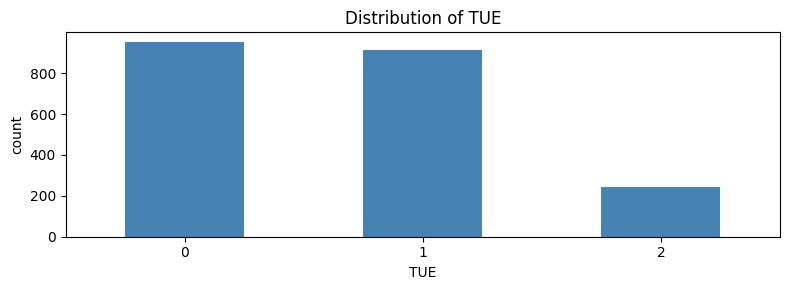

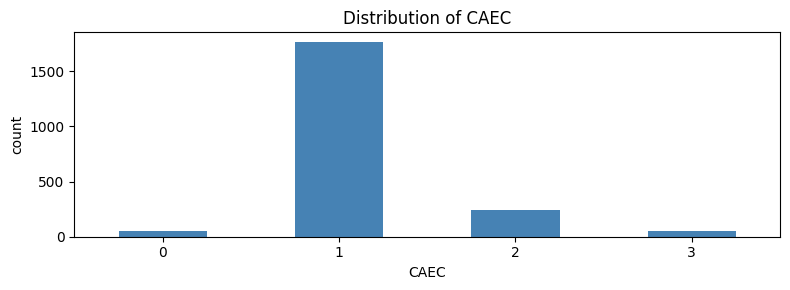

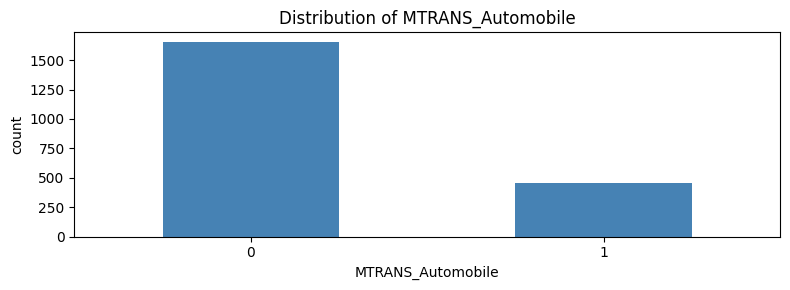

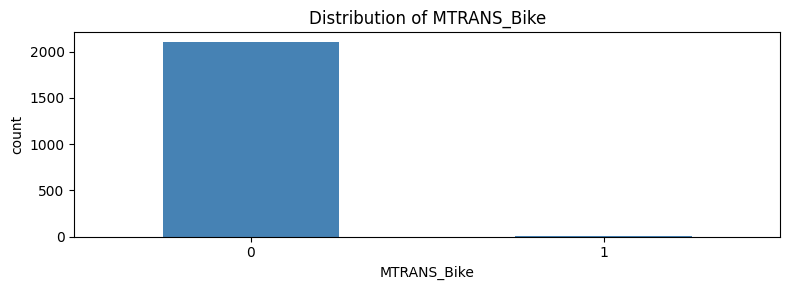

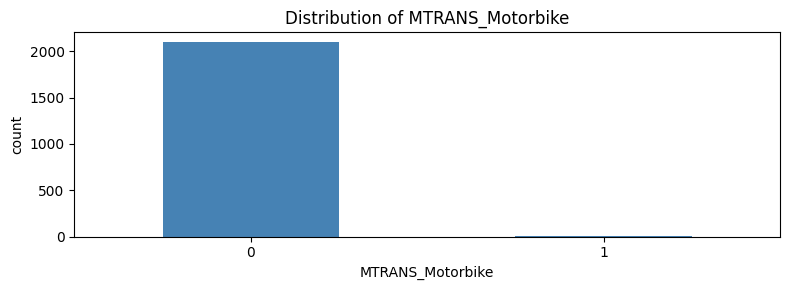

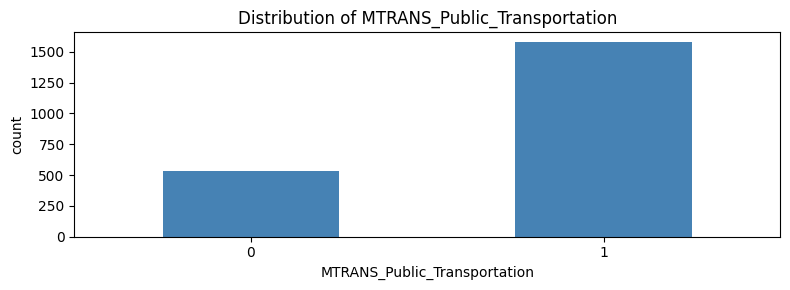

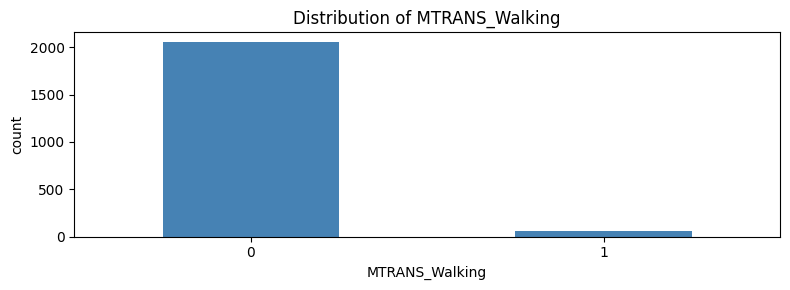

In [ ]:
# Exclude target column from distribution plots
plot_features = [col for col in categorical_features if col != 'NObeyesdad']

for col in plot_features:
    plt.figure(figsize=(8, 3))
    categorical_data[col].value_counts().sort_index().plot(
        kind='bar', rot=0, xlabel=col, ylabel='count', color='steelblue'
    )
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

### **Correlation Analysis**
### **Correlation matrix of whole dataset**

In [ ]:
correlation_matrix = dataset.corr(numeric_only=True)
correlation_matrix

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,...,family_history_with_overweight,FAF,TUE,CAEC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
Age,1.000000,0.047701,-0.025958,0.202567,0.044487,0.063902,0.005366,-0.043367,-0.116283,0.091987,...,0.205292,-0.132737,-0.285801,-0.083739,0.282913,0.604683,0.003652,0.020286,-0.554448,-0.063064
Gender,0.047701,1.000000,0.609841,0.157415,-0.009182,0.064730,-0.260826,0.063096,-0.099752,0.043597,...,0.102503,0.188264,-0.004394,-0.091808,-0.032374,0.135892,0.056571,0.044659,-0.160176,0.043967
Height,-0.025958,0.609841,1.000000,0.462924,0.129732,0.178364,-0.053772,0.244055,-0.133753,0.055499,...,0.245543,0.290594,0.058097,-0.048818,0.133565,0.077851,0.028996,-0.010471,-0.089684,0.036951
Weight,0.202567,0.157415,0.462924,1.000000,0.206874,0.272228,0.179623,0.103261,-0.201861,0.025721,...,0.494995,-0.048124,-0.039499,-0.287357,0.913293,-0.013798,-0.021754,-0.037312,0.059531,-0.100876
CALC,0.044487,-0.009182,0.129732,0.206874,1.000000,0.089520,0.044279,0.077209,0.003463,0.082471,...,-0.036073,-0.081355,-0.032960,-0.047540,0.151752,-0.011723,-0.017905,-0.026113,0.024101,-0.016923
FAVC,0.063902,0.064730,0.178364,0.272228,0.089520,1.000000,-0.031019,-0.006363,-0.190658,-0.050660,...,0.208691,-0.099741,0.063278,-0.150068,0.247793,0.057597,-0.082005,-0.035401,0.028539,-0.179473
FCVC,0.005366,-0.260826,-0.053772,0.179623,0.044279,-0.031019,1.000000,0.011111,0.075343,0.007760,...,0.024448,0.013661,-0.077269,0.054086,0.195705,-0.070020,-0.027729,-0.007421,0.067095,0.011535
NCP,-0.043367,0.063096,0.244055,0.103261,0.077209,-0.006363,0.011111,1.000000,-0.014132,0.007110,...,0.060869,0.130322,0.013010,0.094589,0.020931,0.057779,0.022244,0.003527,-0.060374,0.005396
SCC,-0.116283,-0.099752,-0.133753,-0.201861,0.003463,-0.190658,0.075343,-0.014132,1.000000,0.047731,...,-0.185877,0.069495,-0.012832,0.109179,-0.194508,-0.042965,0.026960,0.047362,0.011255,0.048860
SMOKE,0.091987,0.043597,0.055499,0.025721,0.082471,-0.050660,0.007760,0.007110,0.047731,1.000000,...,0.017224,0.010031,0.008646,0.055282,0.003442,0.011873,-0.008416,0.035496,-0.022409,0.017184


### **Correlation Heatmap plot of whole dataset**

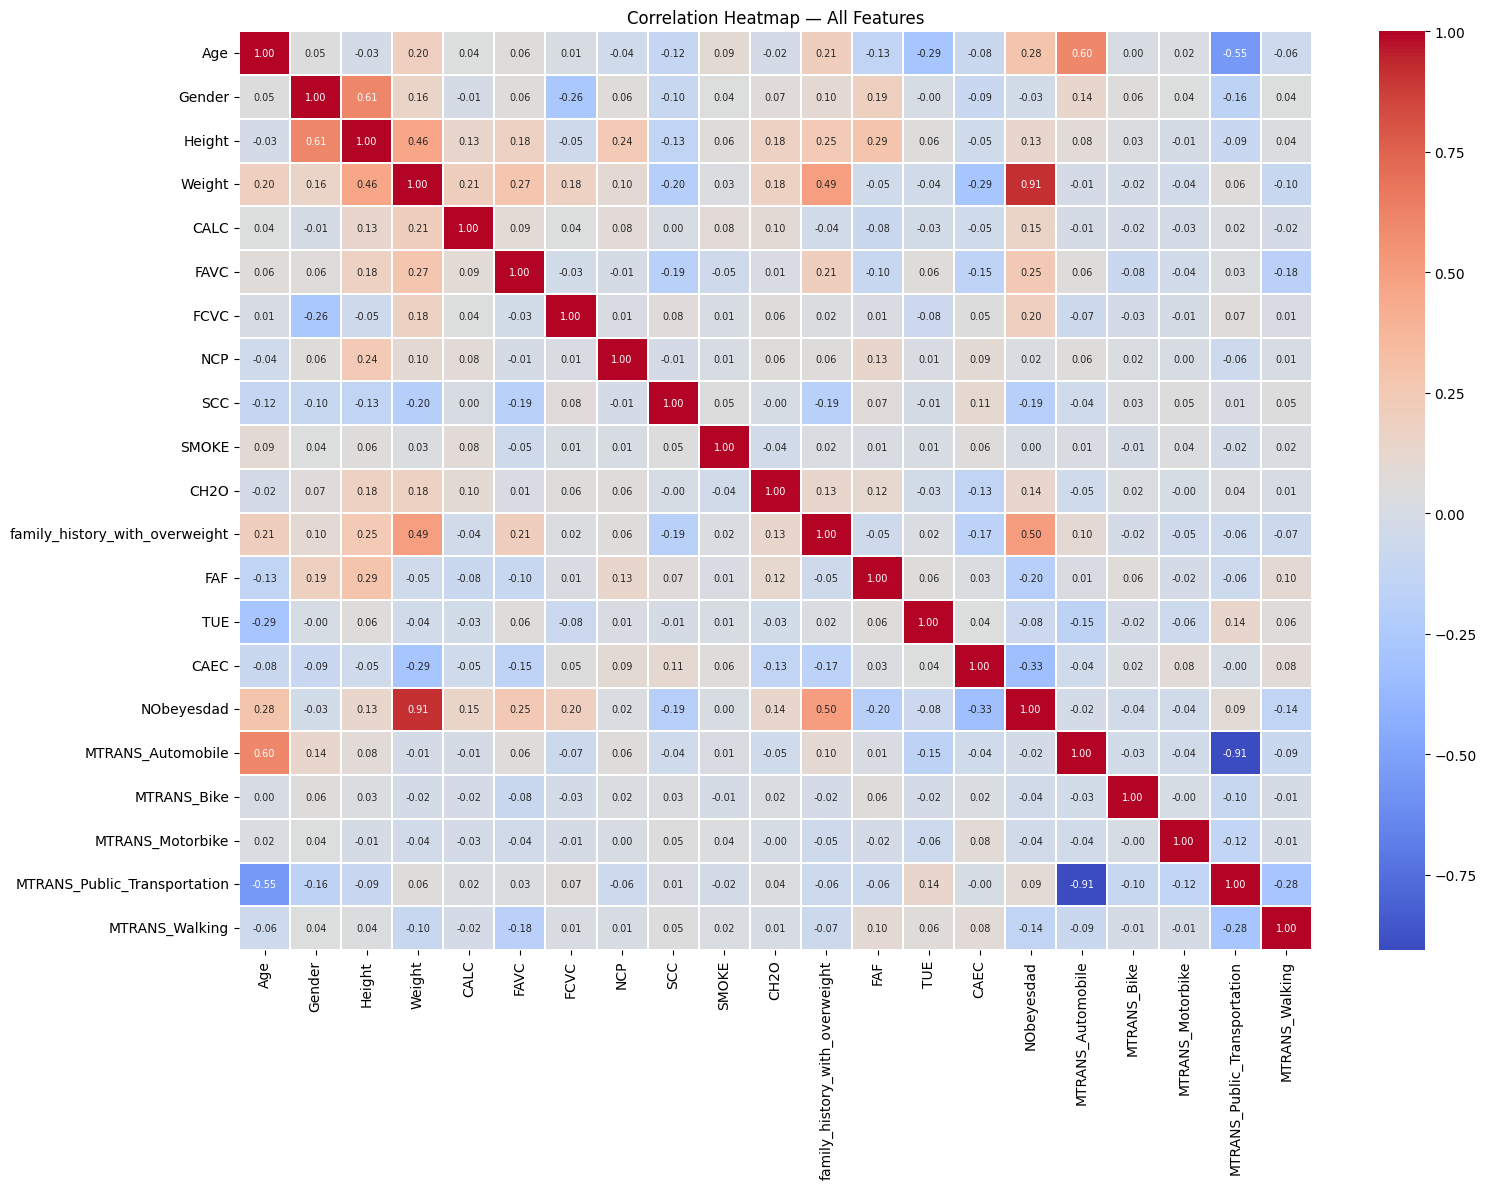

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.3, annot_kws={'size': 7})
plt.title('Correlation Heatmap — All Features')
plt.tight_layout()
plt.show()

### **Generating correlation plot between features and target variable using different methods**

**🔹 Pearson** — linear relationship between continuous variables.

**🔹 Spearman** — monotonic relationship; uses rank values; less sensitive to outliers; ideal for ordinal features.

**🔹 Kendall's Tau** — measures pairwise concordance; more conservative than Spearman; better for ties.

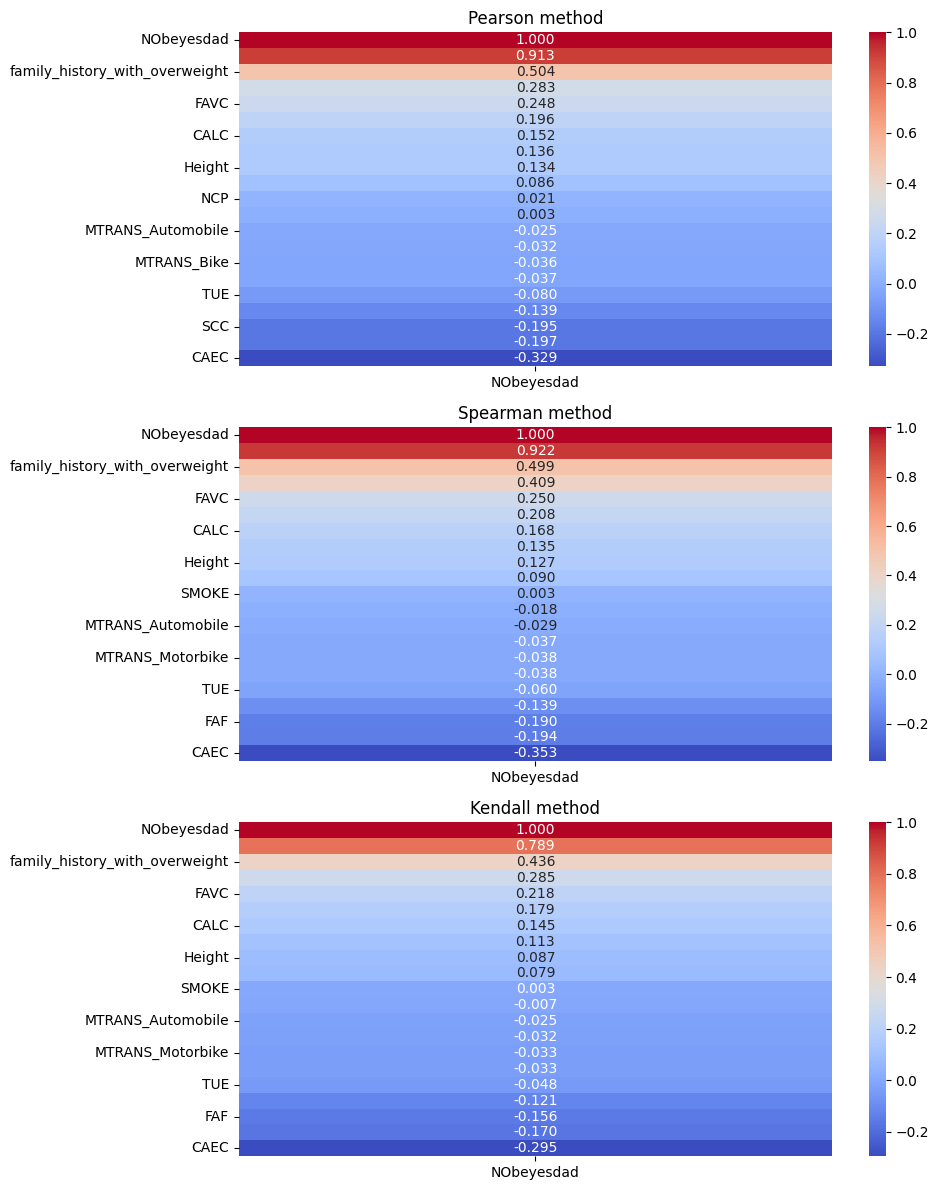

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10, 12))

corr1 = dataset.corr(method='pearson', numeric_only=True)[['NObeyesdad']].sort_values(by='NObeyesdad', ascending=False)
corr2 = dataset.corr(method='spearman', numeric_only=True)[['NObeyesdad']].sort_values(by='NObeyesdad', ascending=False)
corr3 = dataset.corr(method='kendall',  numeric_only=True)[['NObeyesdad']].sort_values(by='NObeyesdad', ascending=False)

ax[0].set_title('Pearson method')
ax[1].set_title('Spearman method')
ax[2].set_title('Kendall method')

sns.heatmap(corr1, ax=ax[0], annot=True, cmap='coolwarm', fmt='.3f')
sns.heatmap(corr2, ax=ax[1], annot=True, cmap='coolwarm', fmt='.3f')
sns.heatmap(corr3, ax=ax[2], annot=True, cmap='coolwarm', fmt='.3f')

plt.tight_layout()
plt.show()

### **Check imbalance in the data**
#### We have a classification problem so we need to check the balance of the given data.

In [ ]:
label_map = {
    0: 'Insufficient_Weight',
    1: 'Normal_Weight',
    2: 'Overweight_Level_I',
    3: 'Overweight_Level_II',
    4: 'Obesity_Type_I',
    5: 'Obesity_Type_II',
    6: 'Obesity_Type_III'
}

class_counts = dataset.groupby('NObeyesdad').size()
total = len(dataset)

imbalance_df = pd.DataFrame({
    'class':      [label_map[i] for i in class_counts.index],
    'count':      class_counts.values,
    'percentage': (class_counts.values / total * 100).round(2)
})
imbalance_df

,class,count,percentage
0,Insufficient_Weight,272,12.88
1,Normal_Weight,287,13.60
2,Overweight_Level_I,290,13.74
3,Overweight_Level_II,290,13.74
4,Obesity_Type_I,351,16.63
5,Obesity_Type_II,297,14.07
6,Obesity_Type_III,324,15.35


### **Bar plot of Class vs Percentage**

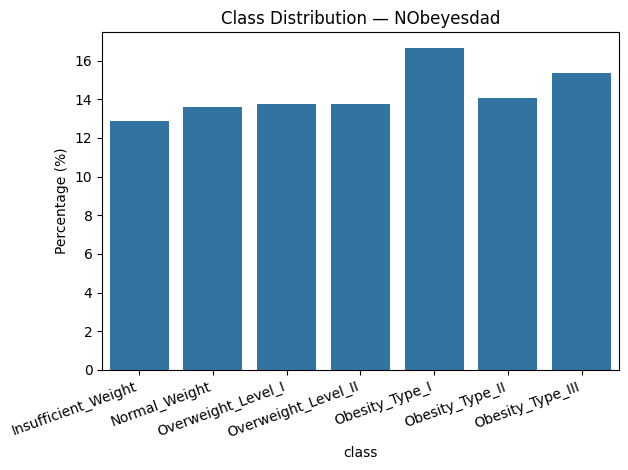

In [ ]:
sns.barplot(data=imbalance_df, x='class', y='percentage')
plt.xticks(rotation=20, ha='right')
plt.title('Class Distribution — NObeyesdad')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

### **Observation**
- Class counts range from **272 (Insufficient Weight, ~12.9%)** to **351 (Obesity Type I, ~16.6%)**
- The imbalance ratio is approximately **1.3:1** — mild, not severe
- We apply **stratified splitting** and **`class_weight='balanced'`** across all models to handle this

### **Data Visualization**
#### Density plots of numerical features

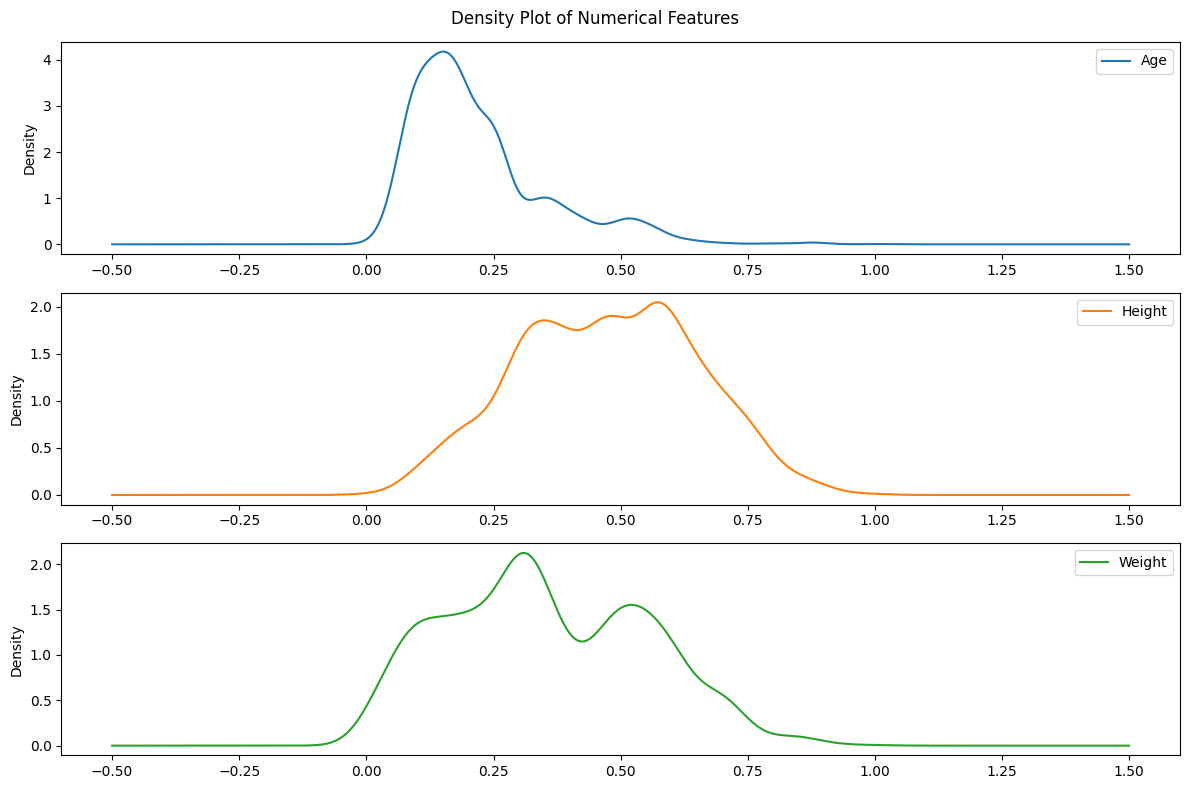

In [ ]:
numerical_data.plot(
    kind='density', figsize=(12, 8),
    subplots=True, layout=(3, 1),
    title='Density Plot of Numerical Features',
    sharex=False
)
plt.tight_layout()
plt.show()

---
# **DATA SPLITTING**

**Strategy: Stratified Split** — 7 classes with slightly different frequencies require stratified splitting to guarantee each split mirrors the original class proportions.

**Split: 70% Train / 15% Validation / 15% Test** — Validation set monitors Neural Network training and detects overfitting before final test evaluation.

In [ ]:
X = dataset.drop('NObeyesdad', axis=1)
y = dataset['NObeyesdad']

# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: 30% temp → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTotal          : {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]}")
print(f"\nFeatures       : {X_train.shape[1]}")

Training set   : 1477 samples (70.0%)
Validation set : 317 samples (15.0%)
Test set       : 317 samples (15.0%)

Total          : 2111

Features       : 20


In [ ]:
# Verify stratification — class proportions should be similar across all splits
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}
for split_name, y_split in splits.items():
    dist = y_split.value_counts(normalize=True).sort_index().round(3)
    print(f"{split_name}: {dict(dist)}")

Train: {0: np.float64(0.129), 1: np.float64(0.136), 2: np.float64(0.137), 3: np.float64(0.137), 4: np.float64(0.166), 5: np.float64(0.141), 6: np.float64(0.154)}
Validation: {0: np.float64(0.129), 1: np.float64(0.136), 2: np.float64(0.139), 3: np.float64(0.139), 4: np.float64(0.167), 5: np.float64(0.139), 6: np.float64(0.151)}
Test: {0: np.float64(0.129), 1: np.float64(0.136), 2: np.float64(0.136), 3: np.float64(0.136), 4: np.float64(0.167), 5: np.float64(0.142), 6: np.float64(0.155)}


---
# **ENCODING & SCALING**

> **Note:** Encoding was already applied during preprocessing (binary, ordinal, one-hot). Here we apply **StandardScaler** to normalize all features to zero mean and unit variance. This is essential for distance-based models (KNN) and gradient-based models (Logistic Regression, Neural Network). Decision Tree and Naive Bayes are less sensitive to scaling but we apply it uniformly for consistency.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_val_scaled   = scaler.transform(X_val)          # apply same transform
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=X_val.columns,   index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print("Scaling complete. Sample of scaled training data:")
X_train_scaled.head()

Scaling complete. Sample of scaled training data:


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
1791,-0.058509,0.981884,-0.923914,0.530295,-1.401081,0.364237,0.996905,-0.844222,-0.216276,-0.146419,-1.506258,0.470819,-0.001523,0.524616,-0.296091,-0.537430,-0.063866,-0.078299,0.592728,-0.162503
1910,-0.452080,-1.018450,1.112428,2.886330,0.515027,0.364237,0.996905,0.389127,-0.216276,-0.146419,-0.035840,0.470819,-1.126048,0.524616,-0.296091,-0.537430,-0.063866,-0.078299,0.592728,-0.162503
1316,2.425259,0.981884,0.965450,0.453048,0.515027,0.364237,-0.731298,-0.844222,-0.216276,-0.146419,1.434579,0.470819,-0.001523,0.524616,-0.296091,1.860708,-0.063866,-0.078299,-1.687114,-0.162503
1632,0.733350,0.981884,2.244734,1.689001,0.515027,0.364237,-0.731298,0.389127,-0.216276,-0.146419,-1.506258,0.470819,-0.001523,-0.968367,-0.296091,-0.537430,-0.063866,-0.078299,0.592728,-0.162503
145,-0.534788,0.981884,-0.860279,-0.628410,0.515027,0.364237,-0.731298,-2.077572,-0.216276,-0.146419,1.434579,-2.123957,-0.001523,-0.968367,-2.429388,-0.537430,-0.063866,-0.078299,0.592728,-0.162503


In [ ]:
# Compute class weights to handle mild imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights (higher = model penalized more for misclassifying this class):")
for cls, wt in class_weights.items():
    print(f"  Class {cls}: {wt:.4f}")

Class weights (higher = model penalized more for misclassifying this class):
  Class 0: 1.1105
  Class 1: 1.0498
  Class 2: 1.0394
  Class 3: 1.0394
  Class 4: 0.8612
  Class 5: 1.0144
  Class 6: 0.9295


---
# **MODEL TRAINING & TESTING**

We train **5 supervised models** and **1 unsupervised model (KMeans)**. All supervised models are evaluated on the held-out test set. The validation set was used during Neural Network training for monitoring convergence.

## K-Nearest Neighbors (KNN)

KNN classifies each new sample by finding the *k* most similar training samples (by Euclidean distance) and voting on their class. It is a lazy learner — no explicit model is built; instead, the entire training set is retained and consulted at prediction time.

**Choice of k=7:** We chose k=7 (an odd number to avoid ties) as a reasonable starting value for a dataset of ~1,477 training samples with 7 classes. A small k causes noise sensitivity; a large k blurs class boundaries.

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

y_val_pred_knn  = knn_model.predict(X_val_scaled)
y_test_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn      = knn_model.predict_proba(X_test_scaled)

print("KNN Validation Accuracy :", round(accuracy_score(y_val, y_val_pred_knn), 4))
print("KNN Test Accuracy       :", round(accuracy_score(y_test, y_test_pred_knn), 4))

KNN Validation Accuracy : 0.7792
KNN Test Accuracy       : 0.7666


## Decision Tree

A Decision Tree recursively partitions the feature space by finding the attribute split that maximally reduces impurity (Gini index). It produces an interpretable tree of if-else rules.

**`max_depth=10`** prevents the tree from growing arbitrarily deep and memorizing training noise. **`class_weight='balanced'`** adjusts split quality for imbalanced classes.

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
dt_model.fit(X_train_scaled, y_train)

y_val_pred_dt  = dt_model.predict(X_val_scaled)
y_test_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt      = dt_model.predict_proba(X_test_scaled)

print("Decision Tree Validation Accuracy :", round(accuracy_score(y_val, y_val_pred_dt), 4))
print("Decision Tree Test Accuracy       :", round(accuracy_score(y_test, y_test_pred_dt), 4))

Decision Tree Validation Accuracy : 0.9306
Decision Tree Test Accuracy       : 0.8991


## Logistic Regression

Logistic Regression models the probability of each class using a softmax function over a linear combination of features. Despite the name, it is a **classification** model that finds the optimal linear decision boundary for each class pair.

**`max_iter=2000`** ensures convergence given the 20-feature input space. **`class_weight='balanced'`** is applied since the classes have slightly different sizes.

In [ ]:
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_val_pred_lr  = lr_model.predict(X_val_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr      = lr_model.predict_proba(X_test_scaled)

print("Logistic Regression Validation Accuracy :", round(accuracy_score(y_val, y_val_pred_lr), 4))
print("Logistic Regression Test Accuracy       :", round(accuracy_score(y_test, y_test_pred_lr), 4))

Logistic Regression Validation Accuracy : 0.8644
Logistic Regression Test Accuracy       : 0.8738


## Naive Bayes

Naive Bayes is a probabilistic classifier based on Bayes' theorem. It assumes **conditional independence** between features given the class label — a strong assumption that is often violated in practice. We use `GaussianNB` which models each feature's likelihood as a Gaussian (normal) distribution.

This assumption is problematic here because obesity level depends on complex interactions between weight, height, activity, and diet — not independent contributions. We include it as a baseline to illustrate how this assumption affects performance.

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_val_pred_nb  = nb_model.predict(X_val_scaled)
y_test_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb      = nb_model.predict_proba(X_test_scaled)

print("Naive Bayes Validation Accuracy :", round(accuracy_score(y_val, y_val_pred_nb), 4))
print("Naive Bayes Test Accuracy       :", round(accuracy_score(y_test, y_test_pred_nb), 4))

Naive Bayes Validation Accuracy : 0.53
Naive Bayes Test Accuracy       : 0.5237


## Neural Network

A Multilayer Perceptron (MLP) with three hidden layers. It learns complex non-linear decision boundaries through backpropagation. The output layer uses **softmax** activation to produce a probability distribution across the 7 classes. **Dropout layers** are added after the first two hidden layers to regularize the model and reduce overfitting.

**Architecture:** Input(20) → Dense(128, ReLU) → Dropout(0.3) → Dense(64, ReLU) → Dropout(0.2) → Dense(32, ReLU) → Dense(7, Softmax)

In [ ]:
y_train_cat = to_categorical(y_train, num_classes=7)
y_val_cat   = to_categorical(y_val,   num_classes=7)
y_test_cat  = to_categorical(y_test,  num_classes=7)

nn_model = Sequential([
    Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(7, activation='softmax')
])

nn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,255 (51.78 KB)

 Trainable params: 13,255 (51.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Recompute class_weights here so this cell is self-contained
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
_classes = np.unique(y_train)
_weights = compute_class_weight(class_weight='balanced', classes=_classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(_classes, _weights)}

history = nn_model.fit(
    X_train_scaled, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_scaled, y_val_cat),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3026 - loss: 1.8209 - val_accuracy: 0.4763 - val_loss: 1.5575
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4733 - loss: 1.4226 - val_accuracy: 0.6057 - val_loss: 1.1357
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6039 - loss: 1.0887 - val_accuracy: 0.6372 - val_loss: 0.8998
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6737 - loss: 0.8755 - val_accuracy: 0.7256 - val_loss: 0.7122
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7123 - loss: 0.7543 - val_accuracy: 0.7760 - val_loss: 0.6025
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7569 - loss: 0.6806 - val_accuracy: 0.8076 - val_loss: 0.5264
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7840 - loss: 0.6005 - val_accuracy: 0.8170 - val_loss: 0.4816
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7847 - loss: 0.5758 - val_accuracy: 0.8360 - val_loss:

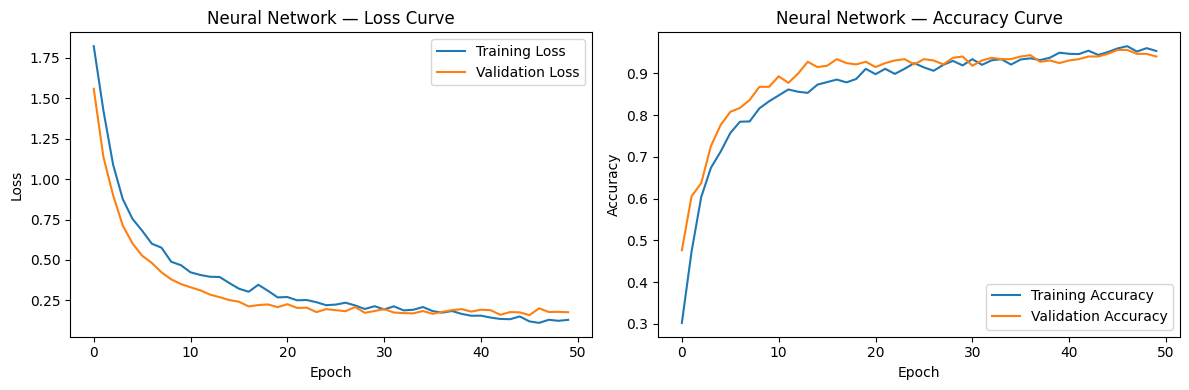

In [ ]:
# Loss curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network — Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network — Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_prob_nn       = nn_model.predict(X_test_scaled)
y_test_pred_nn  = np.argmax(y_prob_nn, axis=1)

y_prob_nn_val   = nn_model.predict(X_val_scaled)
y_val_pred_nn   = np.argmax(y_prob_nn_val, axis=1)

print("Neural Network Validation Accuracy :", round(accuracy_score(y_val, y_val_pred_nn), 4))
print("Neural Network Test Accuracy       :", round(accuracy_score(y_test, y_test_pred_nn), 4))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Neural Network Validation Accuracy : 0.9401
Neural Network Test Accuracy       : 0.9306


---
# **MODEL SELECTION & COMPARISON ANALYSIS**

In [ ]:
# ─── Collect all results ───
results = {}
y_test_bin = label_binarize(y_test, classes=list(range(7)))

model_configs = [
    ('KNN',                 y_test_pred_knn, y_prob_knn),
    ('Decision Tree',       y_test_pred_dt,  y_prob_dt),
    ('Logistic Regression', y_test_pred_lr,  y_prob_lr),
    ('Naive Bayes',         y_test_pred_nb,  y_prob_nb),
    ('Neural Network',      y_test_pred_nn,  y_prob_nn),
]

for name, pred, prob in model_configs:
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred, average='weighted', zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, pred, average='weighted', zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test_bin, prob, multi_class='ovr', average='weighted'), 4),
        'Confusion Matrix': confusion_matrix(y_test, pred)
    }

comparison_df = pd.DataFrame(results).T.drop(columns=['Confusion Matrix'])
display(comparison_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
KNN,0.7666,0.7615,0.7666,0.7572,0.9429
Decision Tree,0.8991,0.9002,0.8991,0.8992,0.9484
Logistic Regression,0.8738,0.8753,0.8738,0.8729,0.9834
Naive Bayes,0.5237,0.4874,0.5237,0.4421,0.8923
Neural Network,0.9306,0.9326,0.9306,0.9304,0.9956


## Accuracy Bar Chart

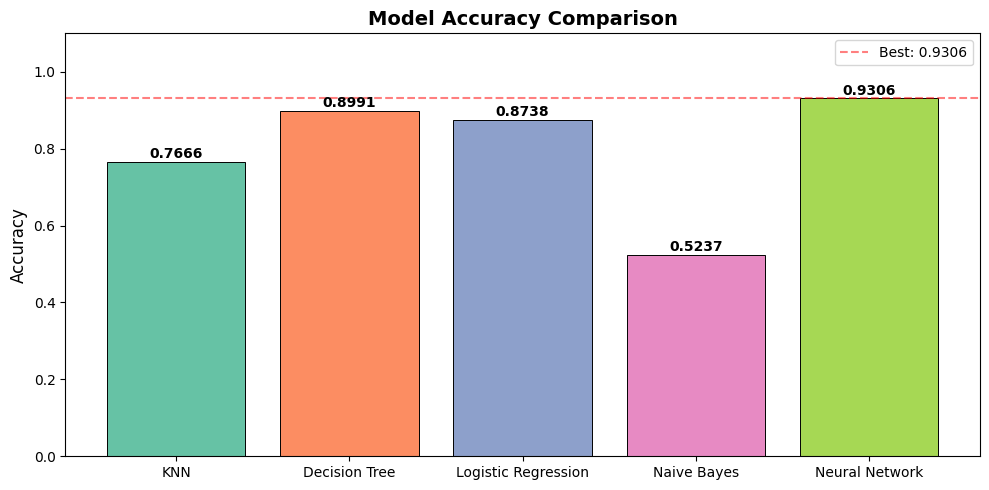

In [ ]:
model_names = list(results.keys())
accuracies  = [results[m]['Accuracy'] for m in model_names]
colors      = sns.color_palette('Set2', len(model_names))

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.7)
plt.ylim(0, 1.1)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.axhline(y=max(accuracies), color='red', linestyle='--', alpha=0.5, label=f'Best: {max(accuracies):.4f}')
plt.legend()
plt.tight_layout()
plt.show()

## Precision, Recall & F1 Score Comparison

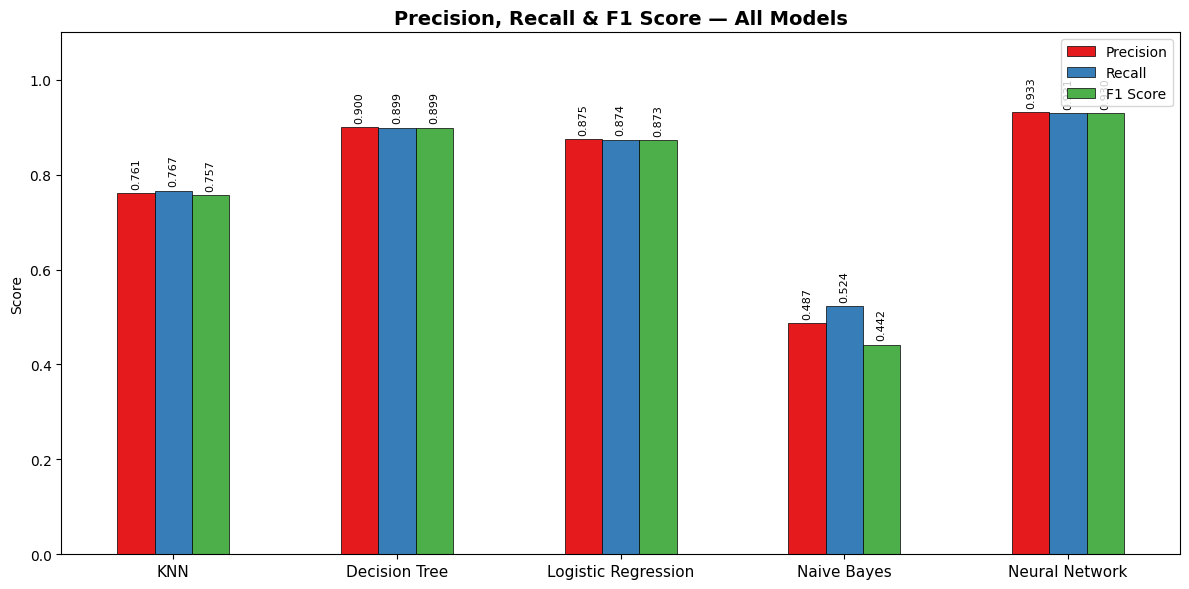

In [ ]:
ax = comparison_df[['Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(12, 6),
    color=sns.color_palette('Set1', 3),
    edgecolor='black', linewidth=0.5
)

plt.title('Precision, Recall & F1 Score — All Models', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, 1.1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', rotation=90, padding=3, fontsize=8)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Confusion Matrices

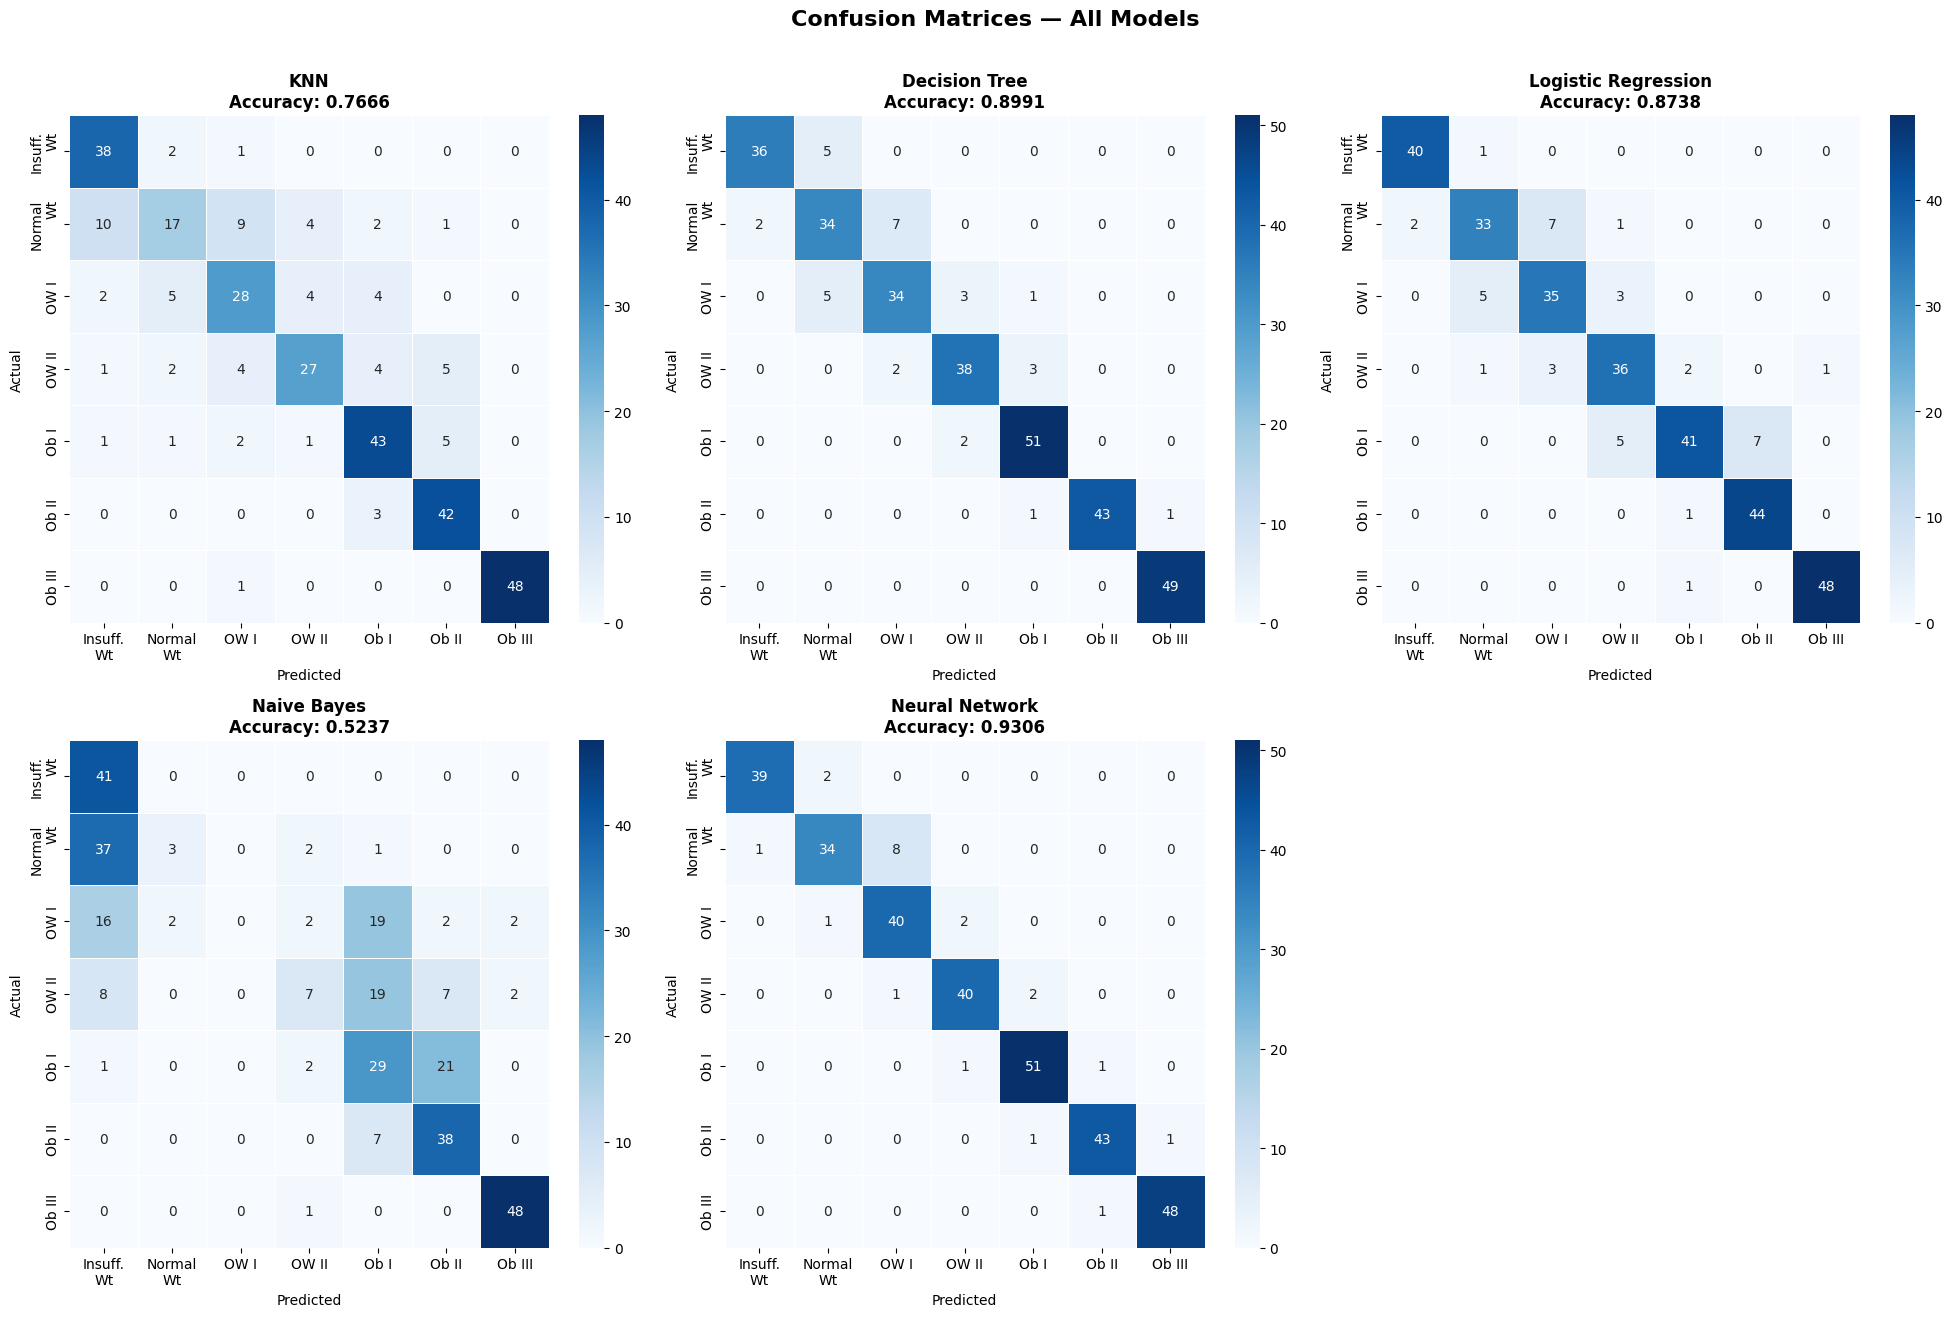

In [ ]:
class_labels = ['Insuff.\nWt', 'Normal\nWt', 'OW I', 'OW II', 'Ob I', 'Ob II', 'Ob III']

preds_dict = {
    'KNN':                 y_test_pred_knn,
    'Decision Tree':       y_test_pred_dt,
    'Logistic Regression': y_test_pred_lr,
    'Naive Bayes':         y_test_pred_nb,
    'Neural Network':      y_test_pred_nn,
}

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for idx, (name, pred) in enumerate(preds_dict.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=axes[idx], linewidths=0.4)
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.4f}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## ROC Curves & AUC Scores

For multiclass problems, ROC is computed using the **One-vs-Rest (OvR)** strategy — each class is treated as a binary problem (class k vs. all others). AUC is then averaged across all 7 classes (weighted by class support).

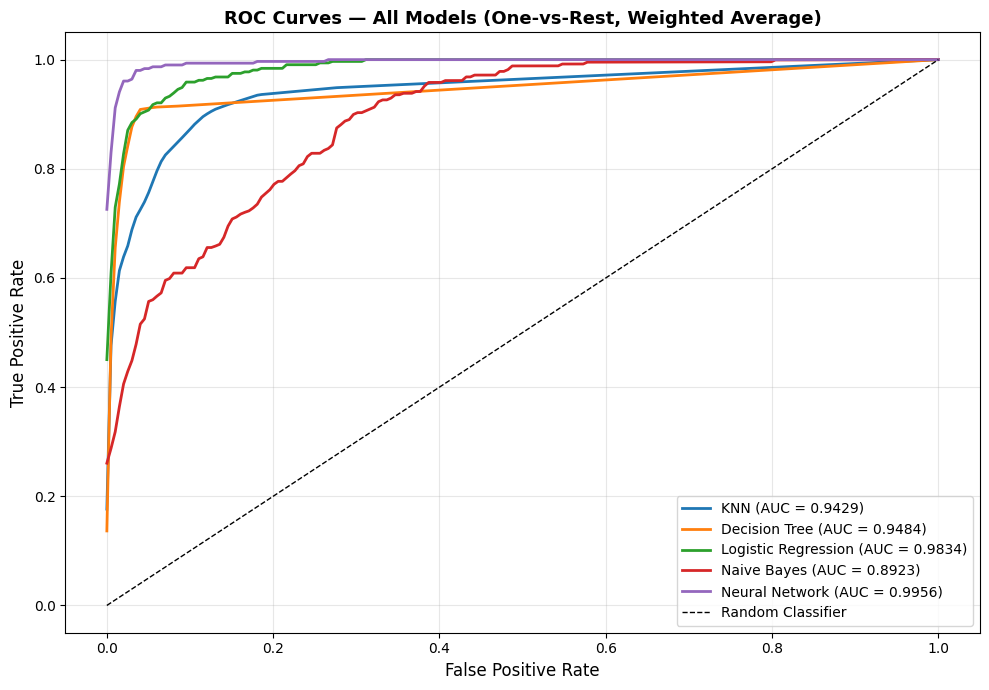


AUC Scores:
  KNN                      : 0.9429
  Decision Tree            : 0.9484
  Logistic Regression      : 0.9834
  Naive Bayes              : 0.8923
  Neural Network           : 0.9956


In [ ]:
y_test_bin = label_binarize(y_test, classes=list(range(7)))
class_names_full = ['Insufficient Weight', 'Normal Weight', 'Overweight I',
                    'Overweight II', 'Obesity I', 'Obesity II', 'Obesity III']

prob_dict = {
    'KNN':                 y_prob_knn,
    'Decision Tree':       y_prob_dt,
    'Logistic Regression': y_prob_lr,
    'Naive Bayes':         y_prob_nb,
    'Neural Network':      y_prob_nn,
}
palette = sns.color_palette('tab10', len(prob_dict))

plt.figure(figsize=(10, 7))

for (name, prob), color in zip(prob_dict.items(), palette):
    auc_score = roc_auc_score(y_test_bin, prob, multi_class='ovr', average='weighted')
    # Macro-average ROC
    fpr_all, tpr_all = [], []
    for i in range(7):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob[:, i])
        fpr_all.append(fpr)
        tpr_all.append(tpr)
    mean_fpr = np.linspace(0, 1, 200)
    mean_tpr = np.mean([np.interp(mean_fpr, fpr_i, tpr_i) for fpr_i, tpr_i in zip(fpr_all, tpr_all)], axis=0)
    plt.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {auc_score:.4f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models (One-vs-Rest, Weighted Average)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAUC Scores:")
for name, prob in prob_dict.items():
    auc = roc_auc_score(y_test_bin, prob, multi_class='ovr', average='weighted')
    print(f"  {name:<25}: {auc:.4f}")

## Train / Validation / Test Accuracy Comparison

KNN                       → Train: 0.8192 | Val: 0.7792 | Test: 0.7666
Decision Tree             → Train: 0.9885 | Val: 0.9306 | Test: 0.8991
Logistic Regression       → Train: 0.8951 | Val: 0.8644 | Test: 0.8738
Naive Bayes               → Train: 0.5498 | Val: 0.5300 | Test: 0.5237
Neural Network            → Train: 0.9939 | Val: 0.9401 | Test: 0.9306


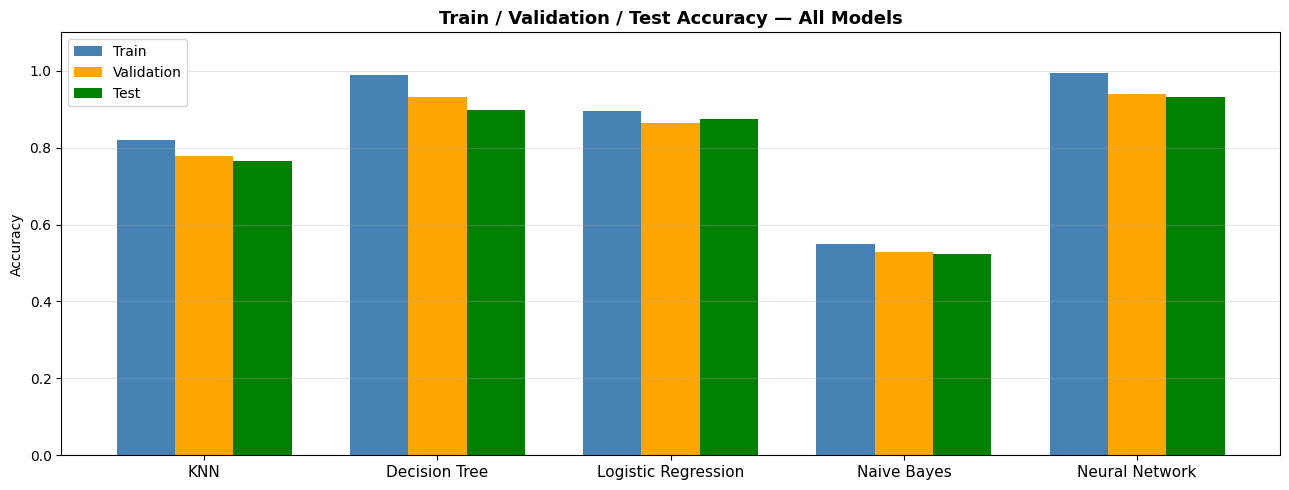

In [ ]:
train_accs, val_accs, test_accs = [], [], []

# Sklearn models
for name, model in [('KNN', knn_model), ('Decision Tree', dt_model),
                    ('Logistic Regression', lr_model), ('Naive Bayes', nb_model)]:
    tr = accuracy_score(y_train, model.predict(X_train_scaled))
    vl = accuracy_score(y_val,   model.predict(X_val_scaled))
    te = accuracy_score(y_test,  model.predict(X_test_scaled))
    train_accs.append(tr); val_accs.append(vl); test_accs.append(te)
    print(f"{name:<25} → Train: {tr:.4f} | Val: {vl:.4f} | Test: {te:.4f}")

# Neural Network
nn_tr = accuracy_score(y_train, np.argmax(nn_model.predict(X_train_scaled, verbose=0), axis=1))
nn_vl = accuracy_score(y_val,   np.argmax(nn_model.predict(X_val_scaled,   verbose=0), axis=1))
nn_te = accuracy_score(y_test,  y_test_pred_nn)
train_accs.append(nn_tr); val_accs.append(nn_vl); test_accs.append(nn_te)
print(f"{'Neural Network':<25} → Train: {nn_tr:.4f} | Val: {nn_vl:.4f} | Test: {nn_te:.4f}")

# Grouped bar chart
x = np.arange(len(model_names))
w = 0.25

plt.figure(figsize=(13, 5))
plt.bar(x - w,  train_accs, w, label='Train',      color='steelblue')
plt.bar(x,      val_accs,   w, label='Validation', color='orange')
plt.bar(x + w,  test_accs,  w, label='Test',       color='green')
plt.xticks(x, model_names, fontsize=11)
plt.ylabel('Accuracy')
plt.title('Train / Validation / Test Accuracy — All Models', fontsize=13, fontweight='bold')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
# **UNSUPERVISED LEARNING — K-Means Clustering**

We treat the obesity classification as an unsupervised problem: we remove all class labels and ask KMeans to discover natural groupings in the data. We then compare discovered clusters against the actual class distribution to see how well the geometric structure aligns with the true obesity levels.

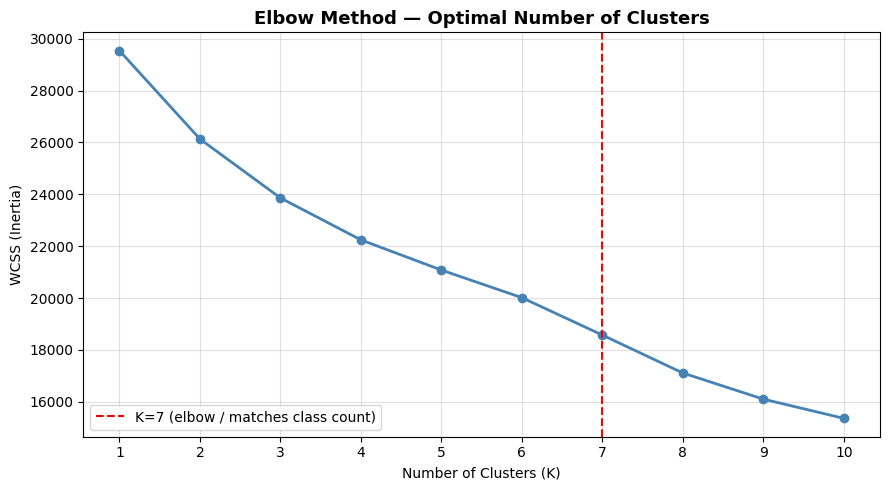

In [ ]:
# Elbow Method — find optimal K
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_train_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.4)
plt.axvline(x=7, color='red', linestyle='--', label='K=7 (elbow / matches class count)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Apply KMeans with K=7 (elbow aligns with number of actual obesity classes)
k_optimal = 7
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
kmeans_final.fit(X_train_scaled)

test_clusters = kmeans_final.predict(X_test_scaled)

print(f"K-Means clustering with K={k_optimal} complete.\n")
print("Cluster distribution in test set:")
cluster_series = pd.Series(test_clusters)
print(cluster_series.value_counts().sort_index())

K-Means clustering with K=7 complete.

Cluster distribution in test set:
0    16
1    98
2    53
3     9
4    60
5    80
6     1
Name: count, dtype: int64


In [ ]:
# Analyze: what % of each cluster corresponds to each actual obesity class
cluster_eval = pd.DataFrame({
    'Cluster':      test_clusters,
    'Actual Class': y_test.values
})

print("Obesity class distribution per cluster (%):\n")
cluster_profile = cluster_eval.groupby('Cluster')['Actual Class'].value_counts(normalize=True).mul(100).round(1)
print(cluster_profile)

Obesity class distribution per cluster (%):

Cluster  Actual Class
0        1                62.5
         0                25.0
         2                 6.2
         3                 6.2
1        4                27.6
         5                25.5
         2                19.4
         3                18.4
         0                 5.1
         1                 4.1
2        6                90.6
         3                 3.8
         2                 1.9
         4                 1.9
         5                 1.9
3        5                55.6
         1                22.2
         2                11.1
         3                11.1
4        4                30.0
         5                23.3
         3                16.7
         0                11.7
         2                10.0
         1                 6.7
         6                 1.7
5        0                31.2
         1                27.5
         2                18.8
         3                13.8
   

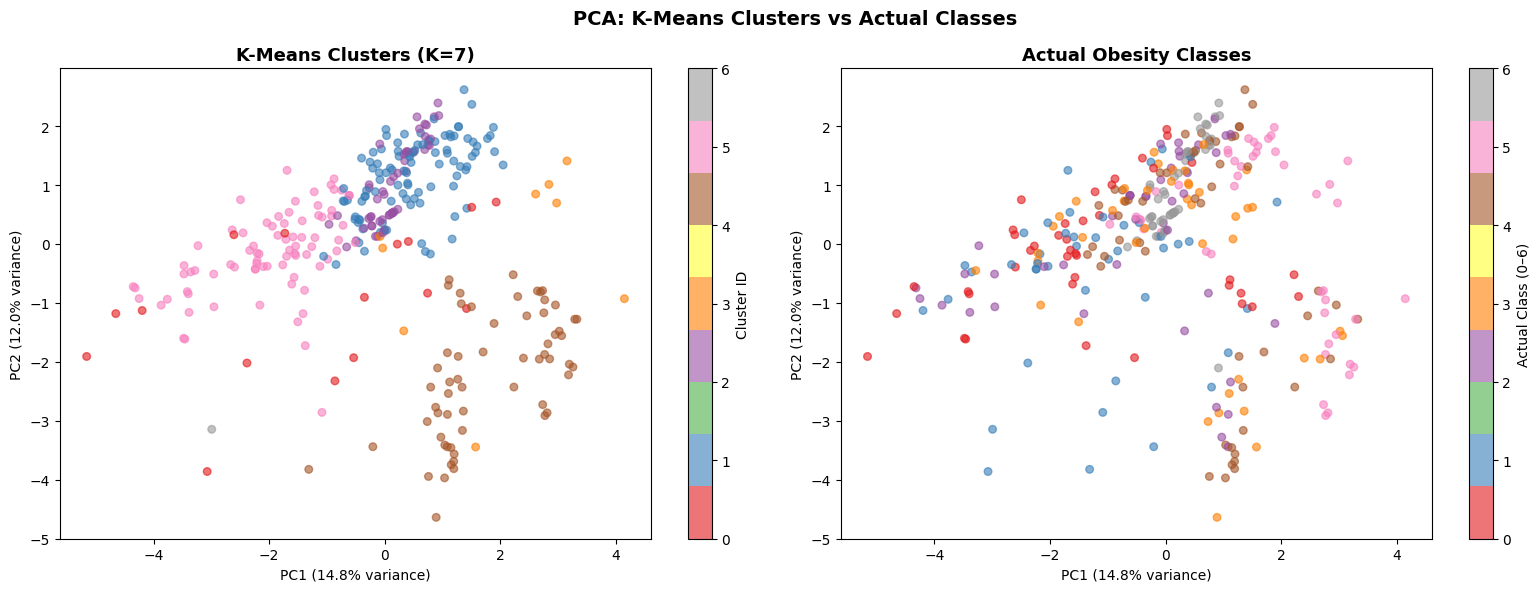

In [ ]:
# Visualize clusters using PCA (reduce 20D → 2D for plotting)
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: KMeans Clusters
scatter1 = axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                            c=test_clusters, cmap='Set1', alpha=0.6, s=30)
axes[0].set_title('K-Means Clusters (K=7)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# Plot 2: Actual Labels
scatter2 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                            c=y_test.values, cmap='Set1', alpha=0.6, s=30)
axes[1].set_title('Actual Obesity Classes', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter2, ax=axes[1], label='Actual Class (0–6)')

plt.suptitle('PCA: K-Means Clusters vs Actual Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

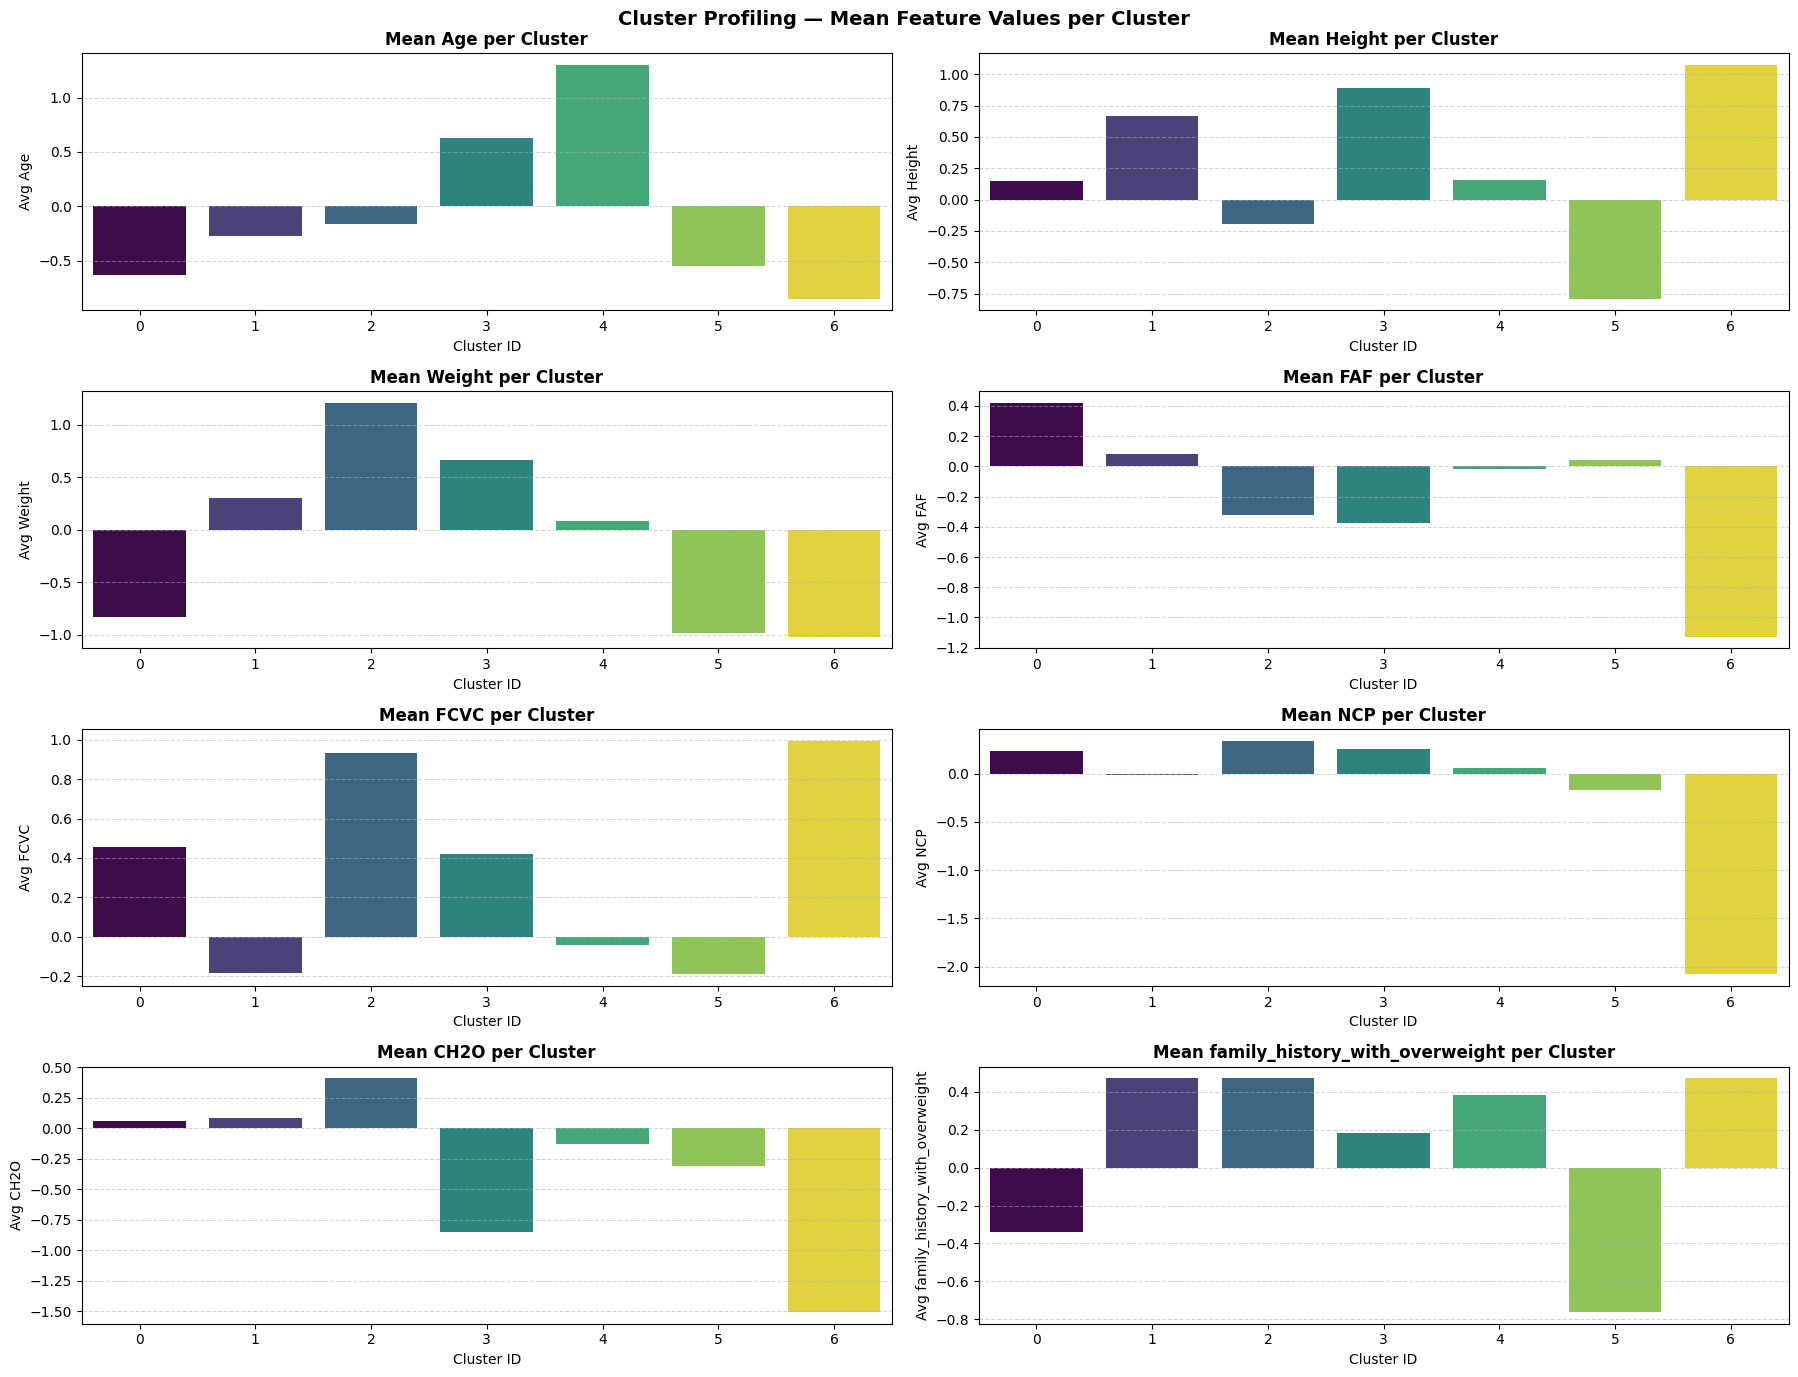

In [ ]:
# Feature mean per cluster — cluster profiling
cluster_profile_df = pd.DataFrame(X_test_scaled, columns=X.columns)
cluster_profile_df['Cluster'] = test_clusters

plot_cols = ['Age', 'Height', 'Weight', 'FAF', 'FCVC', 'NCP', 'CH2O', 'family_history_with_overweight']
plt.figure(figsize=(18, 14))

for i, col in enumerate(plot_cols, 1):
    plt.subplot(4, 2, i)
    sns.barplot(data=cluster_profile_df, x='Cluster', y=col,
                hue='Cluster', palette='viridis', errorbar=None, legend=False)
    plt.title(f'Mean {col} per Cluster', fontsize=12, fontweight='bold')
    plt.xlabel('Cluster ID')
    plt.ylabel(f'Avg {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Cluster Profiling — Mean Feature Values per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()